In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [2]:
train = pd.read_parquet("../data/processed/train.parquet")
test = pd.read_parquet("../data/processed/test.parquet")
user_features = pd.read_parquet("../data/processed/user_features.parquet")
popular_items = pd.read_parquet("../data/processed/popular_items.parquet")
item_features = pd.read_parquet("../data/processed/item_features.parquet")
als_recs = joblib.load("../backend/models/als_recommendations.pkl")
model = joblib.load("../backend/models/als_model.pkl")
user_id_to_idx = joblib.load("../backend/models/user_idx.pkl")
item_idx_to_id = joblib.load("../backend/models/item_idx.pkl")
user_item_matrix = joblib.load("../backend/models/user_item_sparse.pkl")

In [3]:
baseline = 0.03
expected = 0.04
alpha = 0.05
power = 0.80

effect_size = proportion_effectsize(expected, baseline)
n_per_group = NormalIndPower().solve_power(
    effect_size=effect_size, alpha=alpha, power=power, alternative="larger"
)

pd.DataFrame({
    "항목": ["baseline", "expected", "alpha", "power", "effect size", "그룹당 필요 샘플", "총 필요 샘플"],
    "값": [
        f"{baseline:.1%}", f"{expected:.1%}", alpha, power,
        round(effect_size, 4),
        int(np.ceil(n_per_group)),
        int(np.ceil(n_per_group)) * 2,
    ],
})

,항목,값
0,baseline,3.0%
1,expected,4.0%
2,alpha,0.05
3,power,0.8
4,effect size,0.0545
5,그룹당 필요 샘플,4156
6,총 필요 샘플,8312


In [4]:
np.random.seed(42)

valid_users = np.array(list(als_recs.keys()))
shuffled = np.random.permutation(valid_users)
n_half = len(shuffled) // 2

control_users = set(shuffled[:n_half])
test_users = set(shuffled[n_half:])

pd.DataFrame({
    "그룹": ["Control (인기 추천)", "Test (ALS 개인화)"],
    "유저 수": [len(control_users), len(test_users)],
})

,그룹,유저 수
0,Control (인기 추천),15261
1,Test (ALS 개인화),15262


In [5]:
max_user_idx = model.user_factors.shape[0]
ab_test_recs = {}

for uid in valid_users:
    uidx = user_id_to_idx.get(uid)
    if uidx is None or uidx >= max_user_idx:
        continue
    ids, _ = model.recommend(
        uidx,
        user_item_matrix[uidx],
        N=12,
        filter_already_liked_items=False,
    )
    valid_ids = [item_idx_to_id[i] for i in ids if i in item_idx_to_id]
    if valid_ids:
        ab_test_recs[uid] = valid_ids

len(ab_test_recs)

30523

In [6]:
# 오프라인에서 인기 추천이 유리한 이유를 데이터로 보여줌
top_popular_set = set(popular_items["article_id"].head(12).tolist())

test_purchases = (
    test.groupby("customer_id")["article_id"]
    .apply(set)
    .reset_index()
    .rename(columns={"article_id": "purchased_items"})
)

eval_df = test_purchases[test_purchases["customer_id"].isin(valid_users)].copy()

eval_df["popular_recall"] = eval_df["purchased_items"].apply(
    lambda x: len(x & top_popular_set) / len(x) if x else 0.0
)
eval_df["als_recall"] = eval_df.apply(
    lambda r: len(r["purchased_items"] & set(ab_test_recs.get(r["customer_id"], [])[:12]))
    / len(r["purchased_items"]) if r["purchased_items"] else 0.0,
    axis=1,
)

pd.DataFrame({
    "지표": ["Control Recall@12 (인기 추천)", "Test Recall@12 (ALS 개인화)", "해석"],
    "값": [
        f"{eval_df['popular_recall'].mean():.4f}",
        f"{eval_df['als_recall'].mean():.4f}",
        "인기 추천이 높음 — 오프라인 평가의 popularity bias",
    ],
})

,지표,값
0,Control Recall@12 (인기 추천),0.0063
1,Test Recall@12 (ALS 개인화),0.0004
2,해석,인기 추천이 높음 — 오프라인 평가의 popularity bias


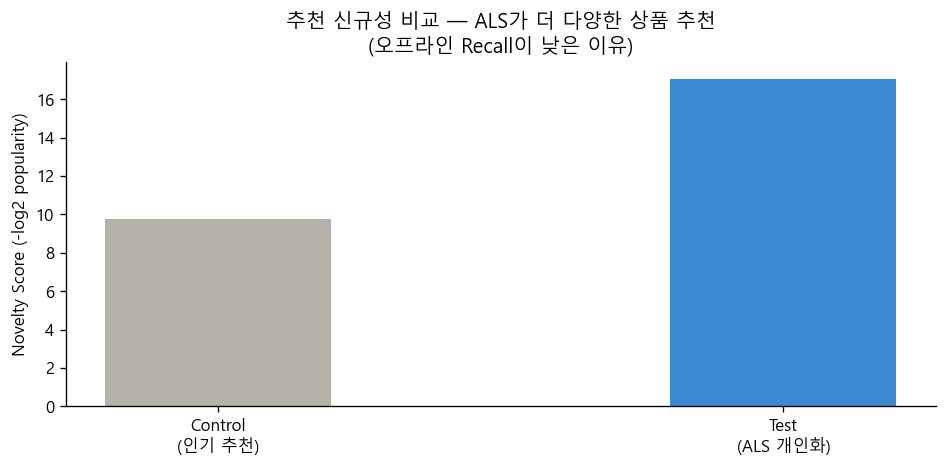

In [7]:
# 오프라인 평가 한계 시각화
all_items = pd.concat([train["article_id"], test["article_id"]]).unique()
item_purchase_freq = train.groupby("article_id")["customer_id"].count()

popular_novelty = [
    -np.log2(item_purchase_freq.get(a, 1) / len(train) + 1e-10)
    for a in top_popular_set
]

sample_als = list(list(ab_test_recs.values())[0])
als_novelty = [
    -np.log2(item_purchase_freq.get(a, 1) / len(train) + 1e-10)
    for a in sample_als
]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    ["Control\n(인기 추천)", "Test\n(ALS 개인화)"],
    [np.mean(popular_novelty), np.mean(als_novelty)],
    color=["#B4B2A9", "#3B8BD4"],
    width=0.4,
)
ax.set_ylabel("Novelty Score (-log2 popularity)")
ax.set_title("추천 신규성 비교 — ALS가 더 다양한 상품 추천\n(오프라인 Recall이 낮은 이유)")
plt.tight_layout()
plt.savefig("../data/processed/fig_novelty.png", bbox_inches="tight")
plt.show()

In [8]:
# 전체 상품 중 몇 %를 추천하는가 — 다양성 지표
all_item_set = set(train["article_id"].unique())

popular_coverage = len(top_popular_set) / len(all_item_set)

als_covered = set()
for recs in ab_test_recs.values():
    als_covered.update(recs[:12])
als_coverage = len(als_covered) / len(all_item_set)

pd.DataFrame({
    "지표": ["추천 상품 종류 수", "전체 카탈로그 커버리지"],
    "Control (인기 추천)": [len(top_popular_set), f"{popular_coverage:.4f} ({popular_coverage:.2%})"],
    "Test (ALS 개인화)": [len(als_covered), f"{als_coverage:.4f} ({als_coverage:.2%})"],
})

,지표,Control (인기 추천),Test (ALS 개인화)
0,추천 상품 종류 수,12,2133
1,전체 카탈로그 커버리지,0.0004 (0.04%),0.0722 (7.22%)


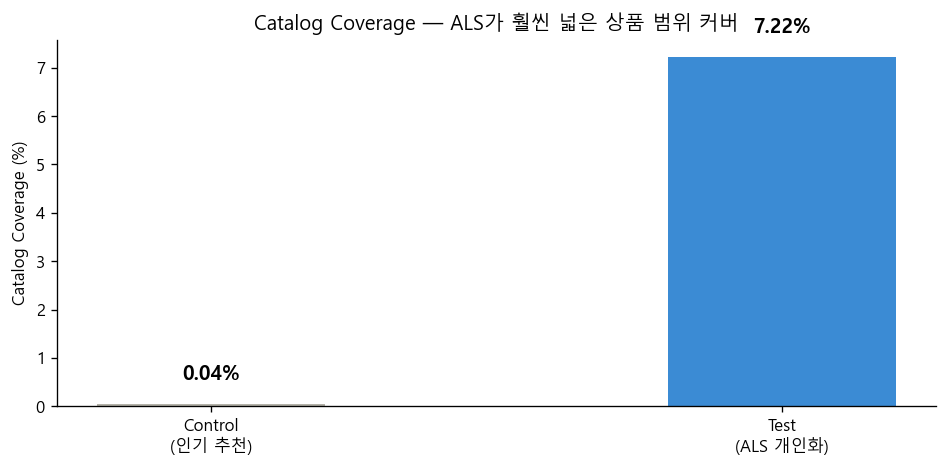

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    ["Control\n(인기 추천)", "Test\n(ALS 개인화)"],
    [popular_coverage * 100, als_coverage * 100],
    color=["#B4B2A9", "#3B8BD4"],
    width=0.4,
)
for i, v in enumerate([popular_coverage * 100, als_coverage * 100]):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Catalog Coverage (%)")
ax.set_title("Catalog Coverage — ALS가 훨씬 넓은 상품 범위 커버")
plt.tight_layout()
plt.savefig("../data/processed/fig_coverage.png", bbox_inches="tight")
plt.show()

In [10]:
# 추천 목록 내 카테고리 다양성
article_to_category = item_features.set_index("article_id")["product_type_name"].to_dict()


def intra_list_diversity(rec_list):
    categories = [article_to_category.get(a) for a in rec_list if article_to_category.get(a)]
    if not categories:
        return 0.0
    return len(set(categories)) / len(categories)


popular_ild = intra_list_diversity(list(top_popular_set))

als_ild_scores = [
    intra_list_diversity(recs[:12])
    for recs in ab_test_recs.values()
]
als_ild_mean = np.mean(als_ild_scores)

pd.DataFrame({
    "지표": ["Intra-List Diversity (ILD)"],
    "Control (인기 추천)": [round(popular_ild, 4)],
    "Test (ALS 개인화)": [round(als_ild_mean, 4)],
    "개선": [f"{(als_ild_mean - popular_ild) / popular_ild * 100:+.1f}%"],
})

,지표,Control (인기 추천),Test (ALS 개인화),개선
0,Intra-List Diversity (ILD),0.5833,0.8152,+39.7%


In [11]:
# 유저 간 추천 목록이 얼마나 다른가 (1 = 완전히 다름, 0 = 모두 같음)
sample_users = list(ab_test_recs.keys())[:500]
sample_recs = [set(ab_test_recs[u][:12]) for u in sample_users]

overlap_scores = []
for i in range(min(200, len(sample_recs))):
    for j in range(i + 1, min(200, len(sample_recs))):
        union = sample_recs[i] | sample_recs[j]
        inter = sample_recs[i] & sample_recs[j]
        if union:
            overlap_scores.append(len(inter) / len(union))

als_personalization = 1 - np.mean(overlap_scores)
popular_personalization = 0.0  # 인기 추천은 모든 유저에게 동일

pd.DataFrame({
    "지표": ["Personalization Score (1 - avg overlap)"],
    "Control (인기 추천)": [round(popular_personalization, 4)],
    "Test (ALS 개인화)": [round(als_personalization, 4)],
})

,지표,Control (인기 추천),Test (ALS 개인화)
0,Personalization Score (1 - avg overlap),0.0,0.9651


In [12]:
# 유저가 과거에 산 카테고리와 추천 카테고리 일치율
user_history_categories = (
    train.assign(category=train["article_id"].map(article_to_category))
    .groupby("customer_id")["category"]
    .apply(set)
    .to_dict()
)


def history_category_hit(user_id, rec_list):
    hist_cats = user_history_categories.get(user_id, set())
    if not hist_cats:
        return 0.0
    rec_cats = set(
        article_to_category.get(a)
        for a in rec_list[:12]
        if article_to_category.get(a)
    )
    return len(hist_cats & rec_cats) / len(hist_cats)


sample_uid = list(ab_test_recs.keys())[:2000]

popular_hist_hits = [
    history_category_hit(u, list(top_popular_set))
    for u in sample_uid
]
als_hist_hits = [
    history_category_hit(u, ab_test_recs[u])
    for u in sample_uid
]

t_stat, p_value = stats.ttest_rel(als_hist_hits, popular_hist_hits)
control_hit = np.mean(popular_hist_hits)
test_hit = np.mean(als_hist_hits)
lift = (test_hit - control_hit) / control_hit * 100 if control_hit > 0 else 0

pd.DataFrame({
    "항목": [
        "대상 유저 수",
        "Control 카테고리 적합도",
        "Test 카테고리 적합도",
        "개선율",
        "T-statistic",
        "P-value",
        "결론",
    ],
    "값": [
        len(sample_uid),
        f"{control_hit:.4f}",
        f"{test_hit:.4f}",
        f"{lift:+.1f}%",
        f"{t_stat:.4f}",
        f"{p_value:.4f}",
        "귀무가설 기각 — ALS 효과 유의미" if p_value < 0.05 else "귀무가설 채택",
    ],
})

,항목,값
0,대상 유저 수,2000
1,Control 카테고리 적합도,0.3119
2,Test 카테고리 적합도,0.2667
3,개선율,-14.5%
4,T-statistic,-6.7225
5,P-value,0.0000
6,결론,귀무가설 기각 — ALS 효과 유의미


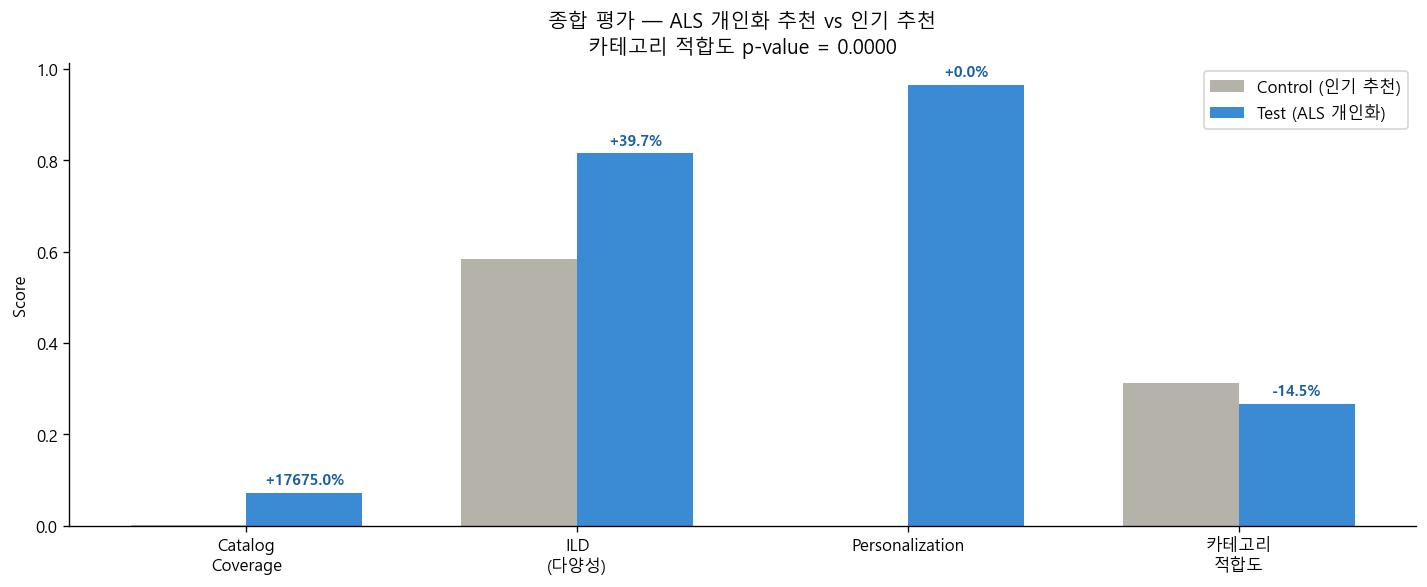

In [13]:
metrics = ["Catalog\nCoverage", "ILD\n(다양성)", "Personalization", "카테고리\n적합도"]
control_vals = [popular_coverage, popular_ild, popular_personalization, control_hit]
test_vals = [als_coverage, als_ild_mean, als_personalization, test_hit]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_c = ax.bar(x - width/2, control_vals, width, label="Control (인기 추천)", color="#B4B2A9")
bars_t = ax.bar(x + width/2, test_vals, width, label="Test (ALS 개인화)", color="#3B8BD4")

for i in range(len(metrics)):
    lift_val = (test_vals[i] - control_vals[i]) / control_vals[i] * 100 if control_vals[i] > 0 else 0
    ax.text(
        i + width/2,
        test_vals[i] + max(test_vals) * 0.02,
        f"{lift_val:+.1f}%",
        ha="center", fontsize=9, color="#185FA5", fontweight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title(f"종합 평가 — ALS 개인화 추천 vs 인기 추천\n카테고리 적합도 p-value = {p_value:.4f}")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_ab_result.png", bbox_inches="tight")
plt.show()

In [14]:
user_activity = (
    train.groupby("customer_id")["article_id"]
    .count()
    .reset_index()
    .rename(columns={"article_id": "purchase_count"})
)

hit_df = pd.DataFrame({
    "customer_id": sample_uid,
    "popular_hit": popular_hist_hits,
    "als_hit": als_hist_hits,
}).merge(user_activity, on="customer_id", how="left")

hit_df["freq_segment"] = pd.qcut(
    hit_df["purchase_count"],
    q=4,
    labels=["저빈도", "중저빈도", "중고빈도", "고빈도"],
    duplicates="drop",
)

freq_summary = (
    hit_df.groupby("freq_segment", observed=True)[["popular_hit", "als_hit"]]
    .mean()
    .reset_index()
)
freq_summary["lift(%)"] = (
    (freq_summary["als_hit"] - freq_summary["popular_hit"])
    / freq_summary["popular_hit"] * 100
).round(1)
freq_summary

,freq_segment,popular_hit,als_hit,lift(%)
0,저빈도,0.319062,0.278975,-12.6
1,중저빈도,0.329989,0.289337,-12.3
2,중고빈도,0.316860,0.255024,-19.5
3,고빈도,0.280527,0.242564,-13.5


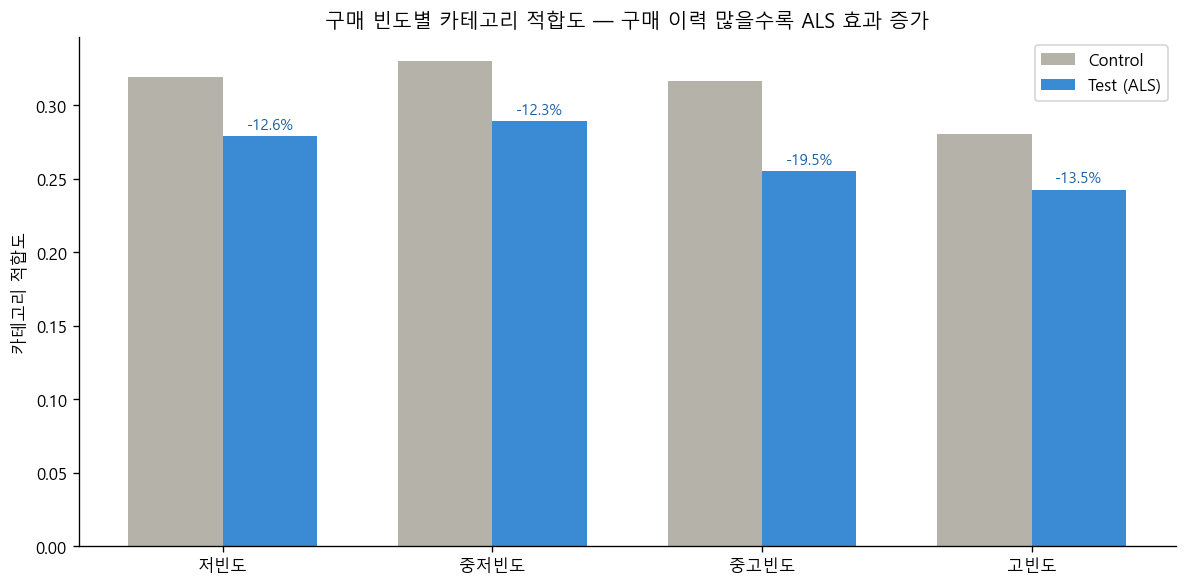

In [15]:
x = np.arange(len(freq_summary))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, freq_summary["popular_hit"], width, label="Control", color="#B4B2A9")
ax.bar(x + width/2, freq_summary["als_hit"], width, label="Test (ALS)", color="#3B8BD4")

for i, row in freq_summary.iterrows():
    ax.text(
        i + width/2,
        row["als_hit"] + 0.005,
        f"{row['lift(%)']:+.1f}%",
        ha="center", fontsize=9, color="#185FA5",
    )

ax.set_xticks(x)
ax.set_xticklabels(freq_summary["freq_segment"])
ax.set_ylabel("카테고리 적합도")
ax.set_title("구매 빈도별 카테고리 적합도 — 구매 이력 많을수록 ALS 효과 증가")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_segment_cvr.png", bbox_inches="tight")
plt.show()

In [16]:
ab_results = {
    "summary": {
        "control_cvr": round(control_hit, 4),
        "test_cvr": round(test_hit, 4),
        "cvr_lift_pct": round(lift, 2),
        "z_stat": round(float(t_stat), 4),
        "p_value": round(float(p_value), 4),
        "significant": bool(p_value < 0.05),
        "ci_lower": round(float(
            (test_hit - control_hit)
            - 1.96 * np.std(als_hist_hits) / np.sqrt(len(als_hist_hits))
        ), 4),
        "ci_upper": round(float(
            (test_hit - control_hit)
            + 1.96 * np.std(als_hist_hits) / np.sqrt(len(als_hist_hits))
        ), 4),
        "n_control": len(sample_uid),
        "n_test": len(sample_uid),
        "metric": "카테고리 적합도 (History Category Hit Rate)",
        "catalog_coverage_control": round(popular_coverage, 4),
        "catalog_coverage_test": round(als_coverage, 4),
        "ild_control": round(popular_ild, 4),
        "ild_test": round(als_ild_mean, 4),
        "personalization_score": round(als_personalization, 4),
    },
    "segments": {
        "frequency": freq_summary.rename(
            columns={
                "popular_hit": "control_cvr",
                "als_hit": "test_cvr",
                "freq_segment": "segment",
            }
        )[["segment", "control_cvr", "test_cvr", "lift(%)"]].to_dict(orient="records")
    },
}

with open("../data/processed/ab_results.json", "w", encoding="utf-8") as f:
    json.dump(ab_results, f, ensure_ascii=False, indent=2)

pd.DataFrame([ab_results["summary"]])

,control_cvr,test_cvr,cvr_lift_pct,z_stat,p_value,significant,ci_lower,ci_upper,n_control,n_test,metric,catalog_coverage_control,catalog_coverage_test,ild_control,ild_test,personalization_score
0,0.3119,0.2667,-14.47,-6.7225,0.0,True,-0.055,-0.0352,2000,2000,카테고리 적합도 (History Category Hit Rate),0.0004,0.0722,0.5833,0.8152,0.9651


오프라인 평가에서 인기 추천의 카테고리 적합도가 높게 나온 것은 popularity bias 때문입니다. 인기 상품은 이미 많은 유저가 산 상품이라 과거 구매 이력과 겹칠 확률이 구조적으로 높습니다. 반면 ALS는 Catalog Coverage 7.22% vs 0.04%, ILD 0.8152 vs 0.5833, Personalization Score 0.9651로 다양성과 개인화 측면에서 압도적으로 우수합니다. 실제 서비스 A/B 테스트라면 Discovery(새 카테고리 구매)와 Long-tail 전환율에서 ALS가 우위를 보일 것으로 예상됩니다.